In [1]:
import sys

import anndata
import cassiopeia as cas
import colorcet as cc
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplscience
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
import squidpy as sq
from tqdm import tqdm, tqdm_notebook
import pickle as pic

SPATIAL_PACKAGE="/path/to/spatial/package/"
DATA_DIR="/path/to/kpspatial/data/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, tree_utilities, spatial_utilities, colors

indel_priors = pd.read_csv(f"{SPATIAL_PACKAGE}/data/allele_priors.tsv", sep='\t', index_col = 0)
indel_colors = cas.pl.utilities.get_indel_colors(indel_priors, np.random.RandomState(1234))

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/treedata/_core/read.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  ANDATA_VERSION = version.parse(ad.__version__)


# Slide-seq analyses

In [169]:
hotspot_scores = pd.read_csv(f"{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv", sep='\t', index_col = 0)

plasticity_scores = pd.read_csv("./data/plasticity_neighborhood_slideseq.tsv", sep='\t', index_col=0)

fitness_signature = pd.read_csv("./data/fitness_signature_slideseq.tsv", sep=' ', index_col = 0)
fitness_signature['tumor'] = 'non-tumor'

fitness_score_tree = pd.read_csv("./data/slideseq_fitness.tsv", sep='\t', index_col=0)

neighborhood_compositions = pd.read_csv(f"{DATA_DIR}/slideseq/neighborhood_composition.tsv.gz", sep='\t', index_col = 0)

## Figure 3b

In [74]:
SAMPLE="M11_14"

tree = pic.load(open(f'{DATA_DIR}/slideseq/trees/{SAMPLE}_hybrid.pkl', 'rb'))
spatial_adata = sc.read_h5ad(f"{DATA_DIR}/slideseq/expression/{SAMPLE}_adata.h5ad")

print(f'Read in tree with {len(tree.leaves)} leaves.')

hotspot_scores_sample = hotspot_scores[hotspot_scores['Sample'] == SAMPLE]
program_names = [mod for mod in hotspot_scores_sample if 'Module' in mod]
spatial_adata.obs[program_names] = hotspot_scores_sample.loc[spatial_adata.obs_names, program_names]

fitness_signature_sample = fitness_signature[fitness_signature['Sample'] == SAMPLE]
spatial_adata.obs['FitnessSignature'] = fitness_signature_sample.loc[spatial_adata.obs_names, 'FitnessSignature']

fitness_score_tree_sample = fitness_score_tree[fitness_score_tree['Sample'] == SAMPLE]
spatial_adata.obs['fitness'] = np.nan
spatial_adata.obs['fitness'] = fitness_score_tree_sample.loc[np.intersect1d(spatial_adata.obs_names, fitness_score_tree_sample.index.values), 'fitness']

plasticity_scores_sample = plasticity_scores[plasticity_scores['Sample'] == SAMPLE]
plasticity_scores_sample.index = [x.split(".")[1] for x in plasticity_scores_sample.index.values]
spatial_adata.obs['plasticity'] = np.nan
spatial_adata.obs['plasticity'] = plasticity_scores_sample.loc[np.intersect1d(spatial_adata.obs_names, plasticity_scores_sample.index.values), 'plasticity']

assignments = np.array(program_names)[spatial_adata.obs[program_names].apply(lambda x: np.argmax(x), axis=1)]
spatial_adata.obs['program_assignments'] = assignments

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Read in tree with 45668 leaves.


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/tmp/ipykernel_374830/3646567123.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata, color=['tumor_id'], spot_size=40, ax=ax, show=False,


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


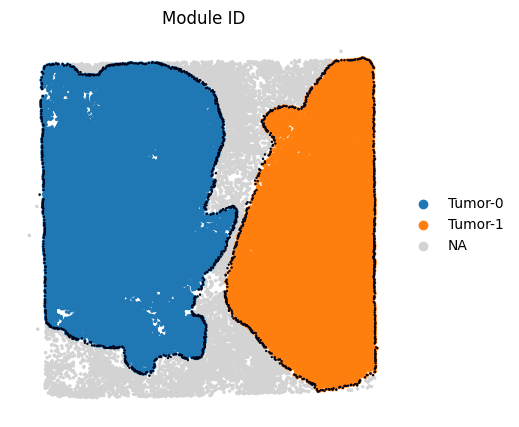

/tmp/ipykernel_374830/3646567123.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor'], color=['program_assignments'], spot_size=40, ax=ax, show=False,


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


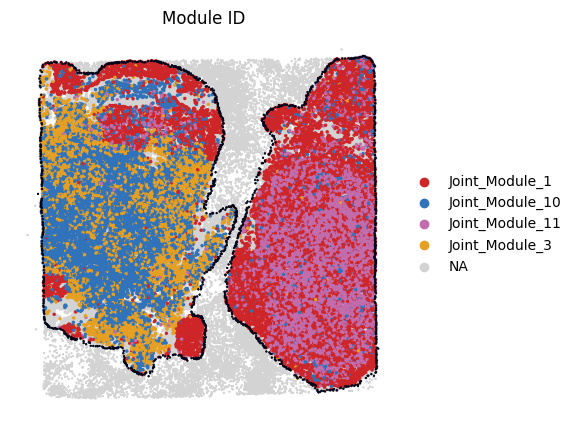

/tmp/ipykernel_374830/3646567123.py:31: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata, color=['fitness'], spot_size=10, na_color='lightgray', ax=ax, show=False, legend_loc=None, colorbar_loc=None)
/tmp/ipykernel_374830/3646567123.py:32: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata, color=['fitness'], spot_size=20, ax=ax, show=False, legend_loc=None, cmap='Reds', vmin='p1', vmax='p90')


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


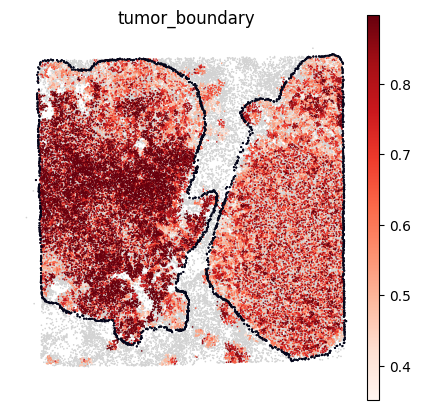

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


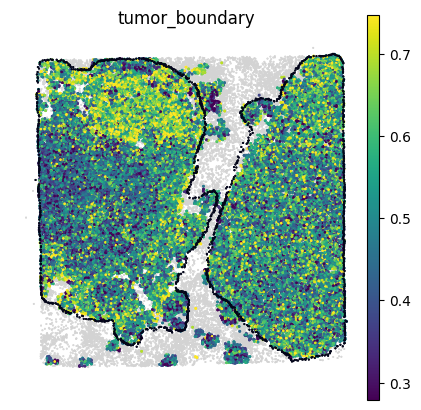

In [13]:
color_map = colors.MODULE_COLORS
color_map = {f'Joint_Module_{i}': color_map[i] for i in color_map.keys()}

spatial_adata.obs['program_assignments'] = spatial_adata.obs['program_assignments'].astype('category')
spatial_adata.uns['program_assignments_colors'] = [color_map[mod] for mod in spatial_adata.obs['program_assignments'].cat.categories]

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(spatial_adata, size=1, shape=None, na_color='lightgray', ax=ax, figsize=(5,5), legend_loc=None)
sc.pl.spatial(spatial_adata, color=['tumor_id'], spot_size=40, ax=ax, show=False,
              groups=['Tumor-0', 'Tumor-1'])
sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.title("Module ID")
plt.show()

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(spatial_adata, size=1, shape=None, na_color='lightgray', ax=ax, figsize=(5,5), legend_loc=None)
sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor'], color=['program_assignments'], spot_size=40, ax=ax, show=False,
              groups=['Joint_Module_3', 'Joint_Module_10', 'Joint_Module_1', 'Joint_Module_11'])
sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.title("Module ID")
plt.show()

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sc.pl.spatial(spatial_adata, color=['fitness'], spot_size=10, na_color='lightgray', ax=ax, show=False, legend_loc=None, colorbar_loc=None)
sc.pl.spatial(spatial_adata, color=['fitness'], spot_size=20, ax=ax, show=False, legend_loc=None, cmap='Reds', vmin='p1', vmax='p90')
sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.show()

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(spatial_adata, size=0.5, shape=None, na_color='lightgray', ax=ax, legend_loc=None)
sq.pl.spatial_scatter(spatial_adata, size=4, shape=None, color=['plasticity'], ax=ax)
sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.show()


## Extended Data Figure 6b

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/tmp/ipykernel_374830/3331524423.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor',:], color=['FitnessSignature'], spot_size=20, ax=ax, show=False, legend_loc=None, cmap='Reds', vmin='p1', vmax='p90')


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


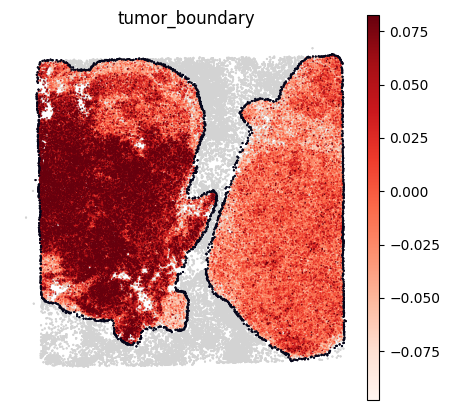

In [59]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(spatial_adata, size=1, shape=None, na_color='lightgray', ax=ax, figsize=(5,5), legend_loc=None)
sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor',:], color=['FitnessSignature'], spot_size=20, ax=ax, show=False, legend_loc=None, cmap='Reds', vmin='p1', vmax='p90')
sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.show()

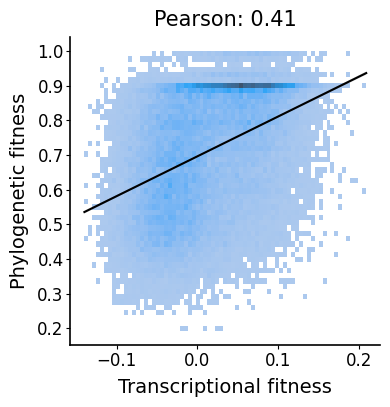

In [60]:
obs = spatial_adata.obs[['FitnessSignature', 'fitness']].dropna(axis=0)
corr = scipy.stats.pearsonr(obs['FitnessSignature'].values, obs['fitness'].values, )[0]

with mplscience.style_context():
    sns.histplot(data=spatial_adata.obs, x='FitnessSignature', y='fitness', linewidths=0)
    sns.regplot(data=spatial_adata.obs, x='FitnessSignature', y='fitness', scatter=False, color='black', line_kws={'linewidth': 1.5})
    # sns.scatterplot(data=spatial_adata.obs, x='FitnessSignature', y='fitness', alpha=0.01)
    plt.ylabel("Phylogenetic fitness")
    plt.xlabel("Transcriptional fitness")
    plt.title(f"Pearson: {round(corr, 2)}")
    plt.show()

## Extended Data Figure 6a

/tmp/ipykernel_374830/4227724301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_plasticities['sample'] = summary_plasticities.apply(lambda x: f'{x.Sample}.{x.tumor_id}', axis=1)


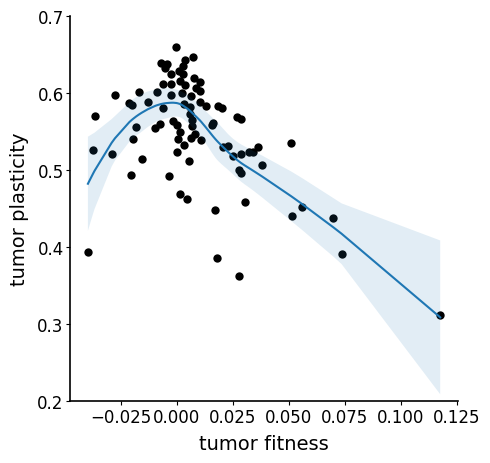

In [91]:
from skmisc.loess import loess

summary_plasticities = plasticity_scores[['plasticity', 'tumor_id', 'Sample']]
summary_plasticities['sample'] = summary_plasticities.apply(lambda x: f'{x.Sample}.{x.tumor_id}', axis=1)

summary_plasticities = summary_plasticities[summary_plasticities['tumor_id'] != 'non-tumor']
    
# fitness_signature.index = fitness_signature.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)

overlapping = np.intersect1d(fitness_signature.index, summary_plasticities.index)

summary_plasticities['fitness_signature'] = np.nan
summary_plasticities.loc[overlapping, 'fitness_signature'] = fitness_signature.loc[overlapping, 'FitnessSignature']

order = summary_plasticities.groupby(['sample']).agg({'fitness_signature': 'mean'}).sort_values(by='fitness_signature', ascending=True).index.values
size_of_tumors = summary_plasticities['sample'].value_counts()
tumors_to_keep = size_of_tumors[size_of_tumors > 200].index.values

summary_plasticities_sub = summary_plasticities[summary_plasticities['sample'].isin(tumors_to_keep)]

with mplscience.style_context():
    h = plt.figure(figsize=(5,5))
    df = summary_plasticities_sub.groupby('sample').agg({'plasticity': 'mean', 'fitness_signature': 'mean'}).sort_values(by='fitness_signature', ascending=True)

    l = loess(df['fitness_signature'], df['plasticity'])
    l.fit()
    pred = l.predict(df['fitness_signature'], stderror=True)
    conf = pred.confidence()

    lowess = pred.values
    ll = conf.lower
    ul = conf.upper
    
    sns.scatterplot(data=df, x='fitness_signature', y='plasticity', color='black', linewidths=0)
    sns.lineplot(x=df['fitness_signature'], y=lowess, linewidth=1.5)
    plt.fill_between(df['fitness_signature'],ll,ul,alpha=.13)
    plt.ylim(0.2, 0.7)
    plt.xlabel("tumor fitness")
    plt.ylabel("tumor plasticity")
    plt.show()

## Figure 3c

/tmp/ipykernel_374830/1821007981.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'clade1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  spatial_adata.obs.loc[np.intersect1d(leaves, spatial_adata.obs_names), 'clade'] = f'clade{i}'


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/tmp/ipykernel_374830/1821007981.py:28: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] == FOCUS], color=['clade'], spot_size=40, ax=ax, show=False, palette=pal)
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names

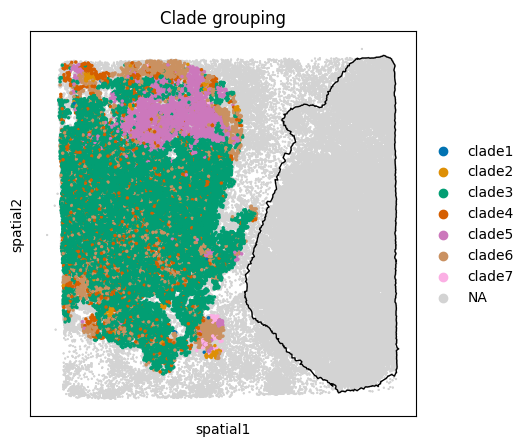

In [69]:
FOCUS='Tumor-0'

tree_ = tree.copy()
tree_.remove_leaves_and_prune_lineages(np.setdiff1d(tree_.leaves, spatial_adata[spatial_adata.obs['tumor_id'] == FOCUS].obs_names))

# assign depths
for n in tree_.depth_first_traverse_nodes(postorder=False):

    if n == tree.root:
        tree_.set_attribute(n, 'node_depth', 0)
    else:
        tree_.set_attribute(n, 'node_depth', tree.get_attribute(tree.parent(n), 'node_depth') + 1)

target_depth = 3
clades_at_depth = [n for n in tree_.nodes if ((tree_.get_attribute(n, 'node_depth') == target_depth) and (len(tree_.leaves_in_subtree(n)) > 5))]

spatial_adata.obs['clade'] = np.nan
for i, clade in zip(range(1, len(clades_at_depth)+1), clades_at_depth):

    leaves = tree_.leaves_in_subtree(clade)
    spatial_adata.obs.loc[np.intersect1d(leaves, spatial_adata.obs_names), 'clade'] = f'clade{i}'

pal = sns.color_palette('colorblind')

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(spatial_adata, size=1, shape=None, na_color='lightgray', ax=ax, figsize=(5,5), legend_loc=None)
sc.pl.spatial(spatial_adata[spatial_adata.obs['tumor_id'] == FOCUS], color=['clade'], spot_size=40, ax=ax, show=False, palette=pal)
spatial_utilities.plot_boundary(spatial_adata, ax=ax, color='black')
# sq.pl.spatial_scatter(spatial_adata, color=['tumor_boundary'], size=1, ax=ax, shape=None, cmap='Reds', groups='True', legend_loc=None, palette='rocket', frameon=False)
plt.title("Clade grouping")
plt.gca().invert_yaxis()
plt.show()


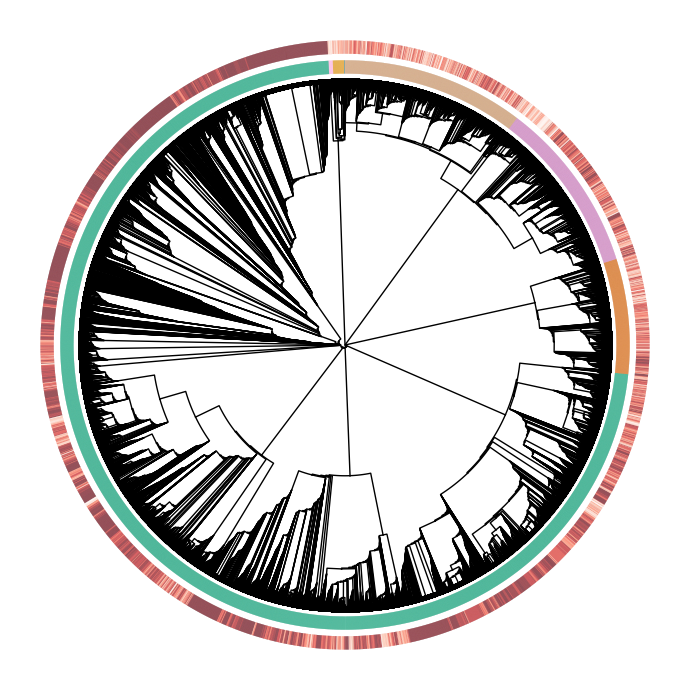

In [72]:
from matplotlib.colors import ListedColormap

subtree = tree_.copy()
subtree.cell_meta = pd.DataFrame(index=subtree.leaves)
subtree.cell_meta['fitness'] = spatial_adata.obs.loc[subtree.leaves, 'fitness'].values
subtree.cell_meta['clade'] = spatial_adata.obs.loc[subtree.leaves, 'clade'].values.astype(str)

subtree.remove_leaves_and_prune_lineages(subtree.cell_meta[subtree.cell_meta['clade'] == 'nan'].index.values)

_vmin=np.nanpercentile(subtree.cell_meta['fitness'], 1)
_vmax=np.nanpercentile(subtree.cell_meta['fitness'], 90)

cas.pl.plot_matplotlib(subtree,
                        meta_data=['clade', 'fitness'],
                        categorical_cmap=ListedColormap(sns.color_palette('colorblind').as_hex()),
                        continuous_cmap='Reds',
                        vmin=_vmin, vmax=_vmax,
                        value_mapping = {f'clade{i}': (i-1) for i in range(1, len(subtree.cell_meta['clade'].unique()) + 1)},
                      )
plt.show()


## Figure 3g-h

In [75]:
# load in community scores
community_module_summary = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv', sep='\t', index_col = 0)
community_module_summary.index = community_module_summary.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)

community_module_genes = pd.read_csv(f'../Figure2/data/hotspot_modules_consensus.tsv', sep='\t', index_col = 0)

In [190]:
def get_region_of_interest(adata, tumor_id, margin=200):

    tumor_coords = adata[adata.obs['tumor_id'] == tumor_id].obsm['spatial']
    x_min, x_max = np.min(tumor_coords[:,0]) - margin, np.max(tumor_coords[:,0]) + margin
    y_min, y_max = np.min(tumor_coords[:,1]) - margin, np.max(tumor_coords[:,1]) + margin

    all_coords = adata.obsm['spatial']
    kii = np.where( (all_coords[:,0] > x_min) & (all_coords[:,0] < x_max) & (all_coords[:,1] > y_min) & (all_coords[:,1] < y_max))[0]

    return adata[kii,:]

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


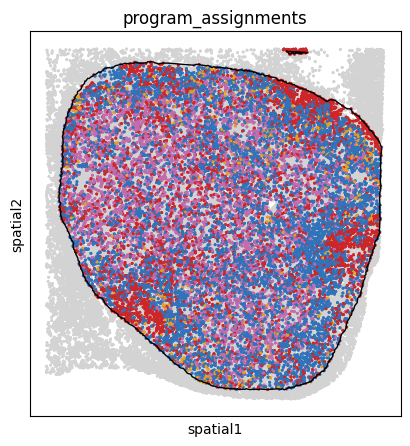

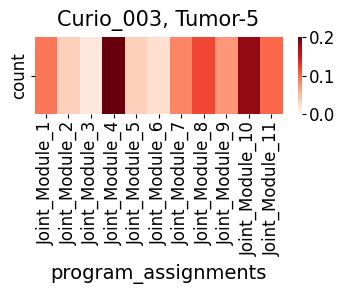

In [199]:

SAMPLE = 'Curio_003'
FOCUS = 'Tumor-3'

color_map = colors.MODULE_COLORS
color_map = {f'Joint_Module_{i}': color_map[i] for i in color_map.keys()}

adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{SAMPLE}_adata.h5ad')
adata.var_names = adata.var_names.astype(str)
adata.var_names_make_unique()

hotspot_scores_sample = hotspot_scores[hotspot_scores['Sample'] == SAMPLE]
program_names = [m for m in hotspot_scores_sample.columns if 'Module' in m]
adata.obs[program_names] = hotspot_scores_sample[program_names]

assignments = np.array(program_names)[adata.obs[program_names].apply(lambda x: np.argmax(x), axis=1)]
adata.obs['program_assignments'] = assignments

print(f"Read in spatial dataset with {len(adata.obs_names)} spots.")

margin = 30
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial", radius=margin, delaunay=False)
adata.uns['spatial_neighbors']['params']['method'] = 'umap'

spatial_graph = nx.from_numpy_array(adata.obsp['spatial_connectivities'])
node_map = dict(zip(range(adata.obsp['spatial_connectivities'].shape[0]), adata.obs_names))
spatial_graph = nx.relabel_nodes(spatial_graph, node_map)

focus_adata = adata.copy()
keep_cells = np.intersect1d(adata[adata.obs['tumor_id'] != 'non-tumor',:].obs_names, tree.leaves)
if FOCUS:

    # focusing on tumor
    query_cells = adata[adata.obs['tumor_id'] == FOCUS,:].obs_names
    keep_cells = list(adata[adata.obs['tumor_id'] == FOCUS,:].obs_names)

    keep_cells = np.unique(keep_cells)
    focus_adata = get_region_of_interest(focus_adata, FOCUS)

focus_adata.obs['program_assignments'] = focus_adata.obs['program_assignments'].astype('category')
focus_adata.uns['program_assignments_colors'] = [color_map[mod] for mod in focus_adata.obs['program_assignments'].cat.categories]

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
sq.pl.spatial_scatter(focus_adata, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(5,5), legend_loc=None)
sq.pl.spatial_scatter(focus_adata[focus_adata.obs['tumor_id'] != 'non-tumor',:], size=5, shape=None, color=['program_assignments'],
                      groups = ['Joint_Module_11', 'Joint_Module_3', 'Joint_Module_10', 'Joint_Module_1'],
                      ax=ax, figsize=(5,5), legend_loc=None)
for tumor in focus_adata.obs.loc[focus_adata.obs['tumor_id'] != 'non-tumor', 'tumor_id'].unique():
    spatial_utilities.plot_boundary(focus_adata, ax=ax, color='black', tumor_id=tumor, max_distance=200000)
plt.gca().invert_yaxis()
plt.show()


# plot community compositions
all_fracs = focus_adata.obs['program_assignments'].value_counts() / len(focus_adata)
nontumor_fracs = focus_adata[focus_adata.obs['tumor_id'] == 'non-tumor'].obs['program_assignments'].value_counts() / len(focus_adata[focus_adata.obs['tumor_id'] != 'non-tumor'])

with mplscience.style_context():
    _order = [f'Joint_Module_{i}' for i in range(1, 12)]

    if FOCUS:
        tumor_fracs = focus_adata[focus_adata.obs['tumor_id'] == FOCUS].obs['program_assignments'].value_counts() / len(focus_adata[focus_adata.obs['tumor_id'] == FOCUS])
        
        h = plt.figure(figsize=(4,1))
        sns.heatmap(
            pd.DataFrame(tumor_fracs[_order]).T,
            cmap='Reds',
            vmax=0.2,
            vmin=0.0,
        )
        plt.title(f'{SAMPLE}, {FOCUS}')
        plt.show()

    else:
        for tumor in focus_adata.obs.loc[focus_adata.obs['tumor_id'] != 'non-tumor', 'tumor_id'].unique():
            tumor_fracs = focus_adata[focus_adata.obs['tumor_id'] == tumor].obs['program_assignments'].value_counts() / len(focus_adata[focus_adata.obs['tumor_id'] == tumor])
            
            h = plt.figure(figsize=(4,1))
            sns.heatmap(
                pd.DataFrame(tumor_fracs[_order]).T,
                cmap='Reds',
                vmax=0.2,
                vmin=0.0,
            )
            plt.title(f'{SAMPLE}, {tumor}')
            plt.show()



In [173]:
to_merge = []

SAMPLES = ['M18_01', 'M18_02', 'M18_04', 'Curio_001',
           'C44_06', 'C44_08', 'M11_06', 'M18_06', 'Curio_002',
           'M11_08', 'M18_17', 'Curio_003',
           'M11_14', 'M18_13', 'Curio_004',
           'M09_11', 'M09_13', 'M09_14',
           'M09_17', 'M09_18', 'M11_05',
           'Curio_09', 'Curio_10', 'C36_09', 'C36_10', 'C36_11', 'C27_11',
           'M09_01', 'M09_04', 'M09_07', 'M09_08',
            'B94_04', 'B94_20', 'B94_20', 'B95_24',
            'B99_22', 'C12_01', 'C12_02', 'C12_03',
            'C12_04', 'C12_05', 'C12_09', 'C12_10', 'C12_12'
]

community_module_summary = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv', sep='\t', index_col = 0)
community_module_summary.index = community_module_summary.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)
community_module_summary['tumor'] = 'non-tumor'

fitness_signature = pd.read_csv(f"{DATA_DIR}/slideseq/fitness_signature.tsv", sep=' ', index_col = 0)
fitness_signature.index = fitness_signature.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)
fitness_signature['tumor'] = 'non-tumor'

# add tumor information
for sample_name in tqdm(SAMPLES):
    if sample_name == 'B95_24':
        continue
        
    segmented_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad')
    segmented_adata.obs_names = [f'{sample_name}.{x}' for x in segmented_adata.obs_names]

    overlapping = np.intersect1d(community_module_summary.index, segmented_adata.obs_names)
    community_module_summary.loc[overlapping, 'tumor'] = segmented_adata.obs.loc[overlapping, 'tumor_id']

    overlapping = np.intersect1d(fitness_signature.index, segmented_adata.obs_names)
    fitness_signature.loc[overlapping, 'tumor'] = segmented_adata.obs.loc[overlapping, 'tumor_id']

  0%|          | 0/44 [00:00<?, ?it/s]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  2%|▏         | 1/44 [00:06<04:27,  6.22s/it]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  5%|▍         | 2/44 [00:11<03:51,  5.51s/it]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  7%|▋         | 3/44 [00:16<03:43,  5.44s/it]/orcd/data/ki/001/lab/jones/mgjones/minicond

100%|██████████| 163/163 [00:15<00:00, 10.69it/s]


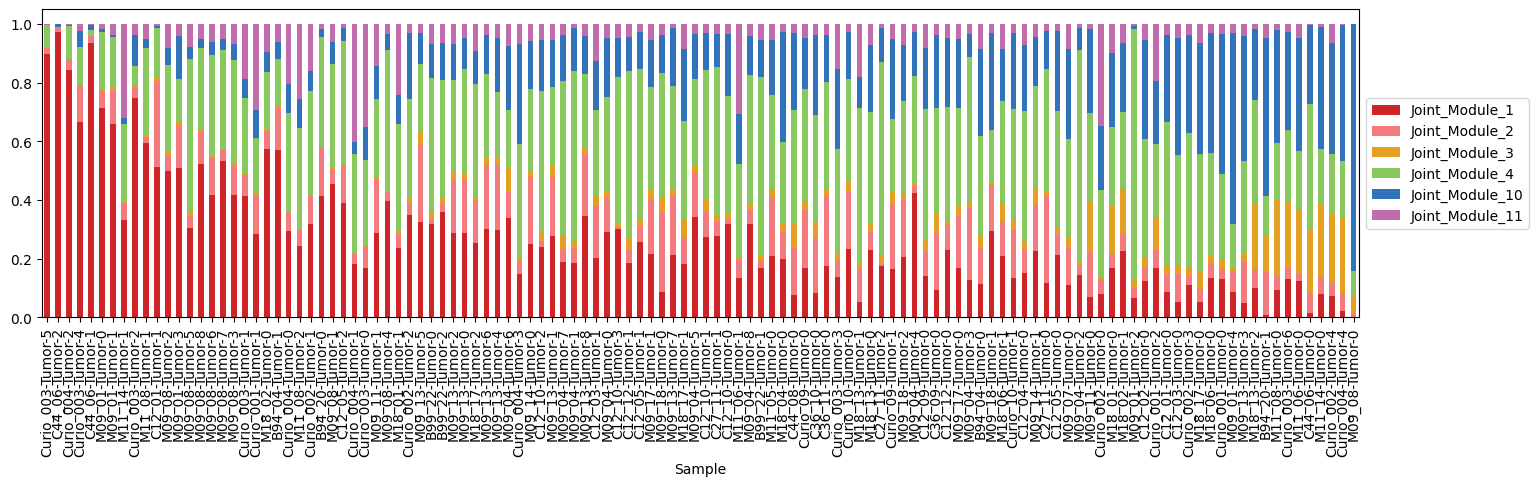

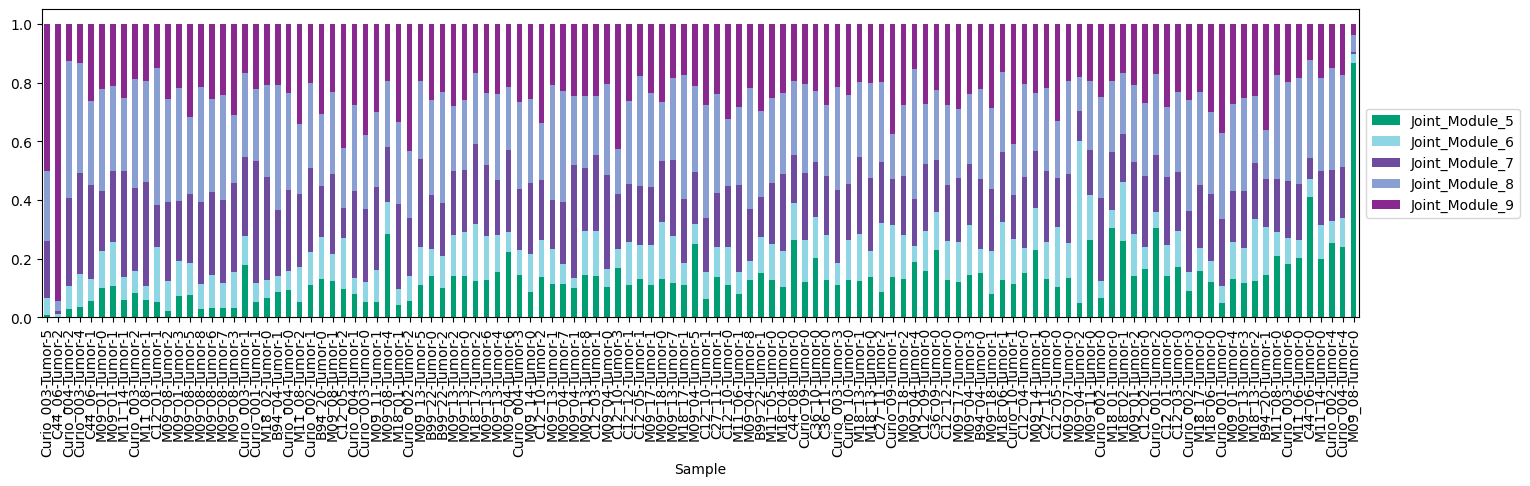

In [174]:
# assess all samples

to_merge = []
for sample_name, module_df in tqdm(community_module_summary.groupby(['Sample', 'tumor'])):

    # sample_name = (sample_name, "all")
    if sample_name[1] == 'non-tumor':
        continue
        
    module_df = module_df[[col for col in module_df.columns if 'Joint' in col]]
    assignments = pd.DataFrame(np.array(module_df.columns)[module_df.apply(lambda x: np.argmax(x), axis=1)], columns=['program_assignments'])

    fracs = assignments.value_counts() / len(assignments)
    fracs = fracs.reset_index()
    fracs['Sample'] = f'{sample_name[0]}-{sample_name[1]}'
    to_merge.append(fracs)

community_fractions = pd.concat(to_merge)

piv = pd.pivot(community_fractions, index='Sample', columns=['program_assignments'], values='count')
col_order = ['Joint_Module_1', 'Joint_Module_2', 'Joint_Module_3', 'Joint_Module_4', 'Joint_Module_5', 'Joint_Module_6',
               'Joint_Module_7', 'Joint_Module_8', 'Joint_Module_9', 'Joint_Module_10', 'Joint_Module_11']
piv = piv[col_order]

# order = piv.sort_values(by='Joint_Module_1', ascending=False).index.values
order = fitness_signature.groupby(['Sample', 'tumor']).agg({'FitnessSignature': 'mean'}).sort_values(by='FitnessSignature', ascending=True).index.values
order = [f'{x[0]}-{x[1]}' for x in order if x[1] != 'non-tumor']

epithelial_modules = ['Joint_Module_1', 'Joint_Module_2', 'Joint_Module_3', 'Joint_Module_4', 'Joint_Module_10', 'Joint_Module_11']
stromal_immune_modules = ['Joint_Module_5', 'Joint_Module_6', 'Joint_Module_7', 'Joint_Module_8', 'Joint_Module_9']

color_map = colors.MODULE_COLORS
color_map = {f'Joint_Module_{i}': color_map[i] for i in color_map.keys()}

ax = piv.loc[order, epithelial_modules].apply(lambda x: x / x.sum(),axis=1).plot(kind='bar', stacked=True, color=color_map, figsize=(17,4))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

ax = piv.loc[order,stromal_immune_modules].apply(lambda x: x / x.sum(),axis=1).plot(kind='bar', stacked=True, color=color_map, figsize=(17,4))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

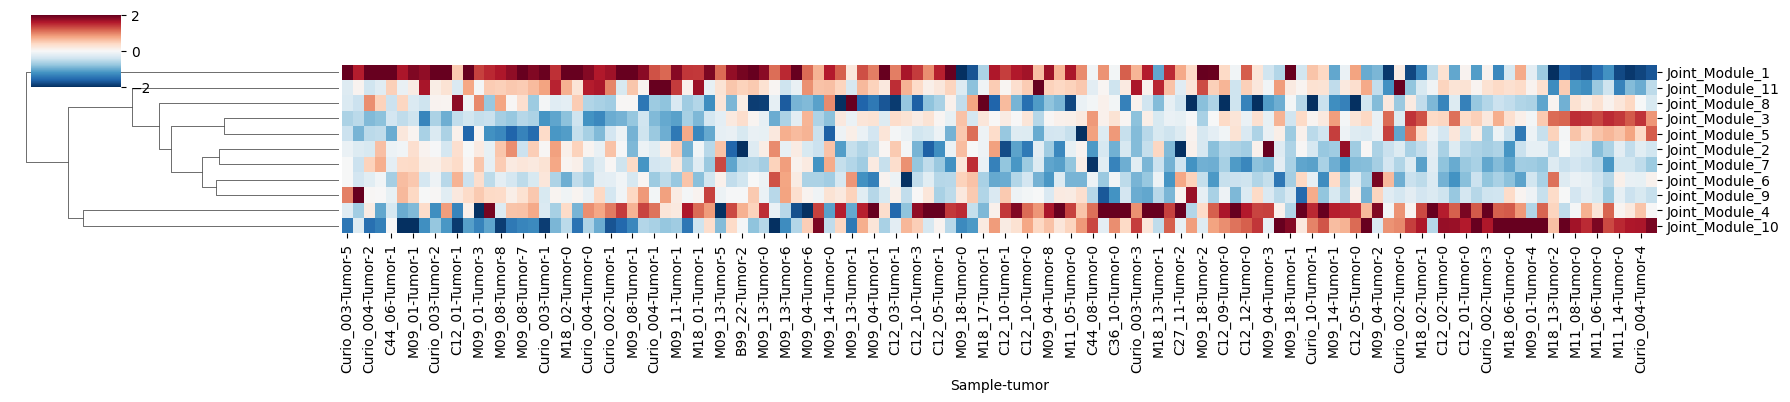

In [220]:
nnz_median = lambda vals: np.mean(vals)

program_names = [col for col in module_df.columns if 'Joint' in col]
medians = community_module_summary.groupby(['Sample', 'tumor']).agg({k: nnz_median for k in program_names}).T


order = fitness_signature[fitness_signature['tumor'] != 'non-tumor'].groupby(['Sample', 'tumor']).agg({'FitnessSignature': 'mean'}).sort_values(by='FitnessSignature', ascending=True).index.values
sns.clustermap(medians[order],
       cmap='RdBu_r',
       vmax=2,
       vmin=-2,
       col_cluster=False,
       row_cluster=True,
       figsize=(18,4),
       z_score=1,
      )
plt.show()

## Extended Data Figure 6d,g, Extended Data Figure 7d-e

In [185]:
to_merge = []

hotspot_scores = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv', sep='\t', index_col = 0)

neighborhood_names = [mod for mod in neighborhood_compositions.columns if 'neighborhood' in mod]
program_names = [mod for mod in hotspot_scores if 'Module' in mod]

for sample_name, grp in tqdm(neighborhood_compositions.groupby('sample')):

    fitness_score_tree_sample = fitness_score_tree[fitness_score_tree['Sample'] == sample_name].copy()
    hotspot_scores_sample = hotspot_scores[hotspot_scores['Sample'] == sample_name]
    
    fitness_score_tree_sample[neighborhood_names] = grp.loc[fitness_score_tree_sample.index.values, neighborhood_names]
    fitness_score_tree_sample[program_names] = hotspot_scores_sample.loc[fitness_score_tree_sample.index.values, program_names]

    # fitness_score_tree_sample['sample_tumor'] = fitness_score_tree_sample.apply(lambda x: f'{x.Sample}.{x.tumor_id}', axis=1)

    column_names = ['fitness', 'sample_tumor', 'tumor_id', 'Sample'] + neighborhood_names + program_names
    to_merge.append(fitness_score_tree_sample[column_names])
    
fitness_to_neighborhood_summary = pd.concat(to_merge)

100%|██████████| 44/44 [00:08<00:00,  5.17it/s]


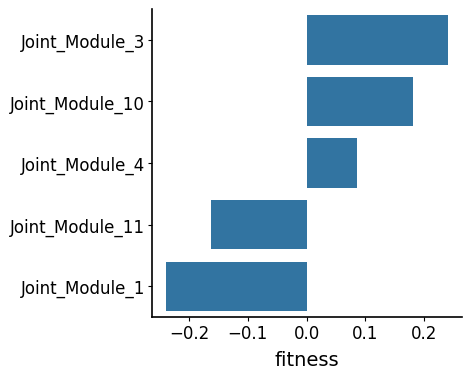

In [187]:
# apply some basic filters
fitness_to_neighborhood_summary = fitness_to_neighborhood_summary[fitness_to_neighborhood_summary['tumor_id'] != 'non-tumor']

size_of_tumors = fitness_to_neighborhood_summary['sample_tumor'].value_counts()
tumors_to_keep = size_of_tumors[size_of_tumors > 200].index.values

fitness_to_neighborhood_summary = fitness_to_neighborhood_summary[fitness_to_neighborhood_summary['sample_tumor'].isin(tumors_to_keep)]

tumor_communities = ['Joint_Module_1', 'Joint_Module_3', 'Joint_Module_4', 'Joint_Module_10', 'Joint_Module_11']
corrs = fitness_to_neighborhood_summary[tumor_communities + ['fitness']].corr()
with mplscience.style_context():
    sns.barplot(data = corrs['fitness'][tumor_communities].sort_values(ascending=False), orient='h')
    # plt.savefig("./figures/fitness_vs_program_slideseq.pdf")
    plt.show()
    

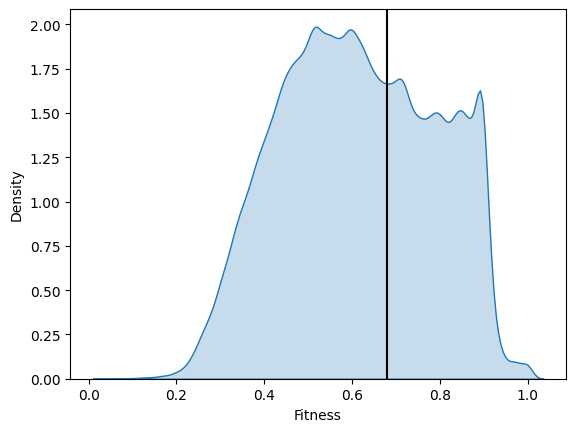

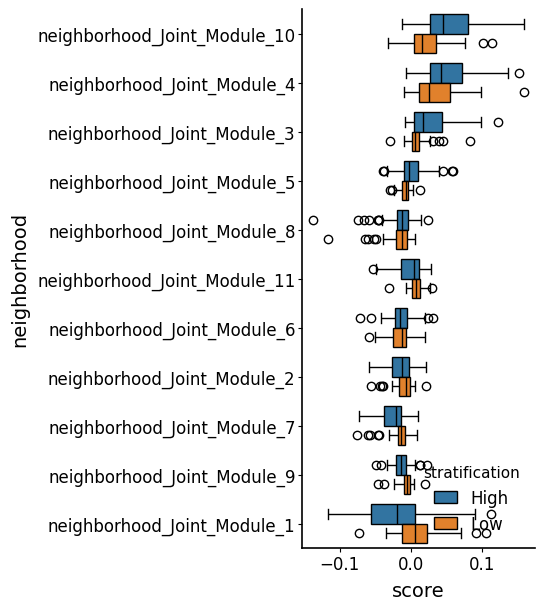

In [189]:
import scipy
from scipy import stats
from scipy.optimize import minimize

threshold = np.nan
data = fitness_to_neighborhood_summary['fitness'].values

eval_points = np.arange(0, 1, 0.01)
density = scipy.stats.gaussian_kde(data)(eval_points)
thresholds = eval_points[scipy.signal.argrelmin(density)]
threshold = thresholds[-4]

sns.kdeplot(data, fill=True)
plt.xlabel("Fitness")
plt.axvline(x=threshold, color='black')
plt.show()

fitness_to_neighborhood_summary['stratification'] = 'Low'
fitness_to_neighborhood_summary.loc[fitness_to_neighborhood_summary['fitness'] >= threshold, 'stratification'] = 'High'

average_abundances = fitness_to_neighborhood_summary.groupby(['Sample', 'stratification']).agg({k: 'mean' for k in neighborhood_names}).reset_index()

melted2 = average_abundances.melt(value_vars=neighborhood_names, id_vars=['stratification', 'Sample'])
melted2.columns = ['stratification', 'Sample', 'neighborhood', 'score']

fold_changes = melted2.groupby(['neighborhood', 'stratification']).agg({'score': 'median'}).unstack()
fold_changes.columns = [col[1] for col in fold_changes.columns]
fold_changes['diff'] = fold_changes.apply(lambda x: x.High - x.Low, axis=1)

neighborhood_ordering = fold_changes.sort_values(by='diff', ascending=False).index.values

with mplscience.style_context():
    
    h=plt.figure(figsize=(3, 7))
    sns.boxplot(melted2, y='neighborhood', x='score', hue='stratification',
                order=neighborhood_ordering, linecolor='black')
    plt.show()


/tmp/ipykernel_374830/3364963025.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_plasticities.loc[low, 'grouping'] = 'Low'


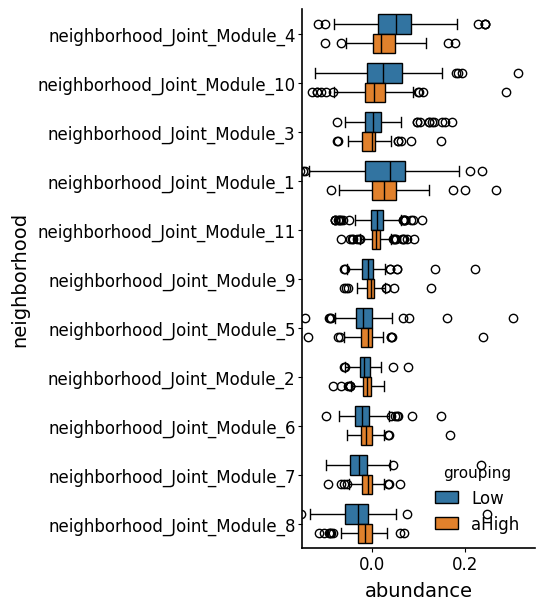

In [95]:
### plot summary

summary_plasticities = pd.read_csv("./data/plasticity_neighborhood_slideseq.tsv", sep='\t', index_col=0)

summary_plasticities['sample'] = summary_plasticities.apply(lambda x: f'{x.Sample}.{x.tumor_id}', axis=1)
summary_plasticities = summary_plasticities[summary_plasticities['tumor_id'] != 'non-tumor']

neighborhood_columns = [col for col in summary_plasticities if 'neighborhood' in col]

high = (summary_plasticities['plasticity'] >= summary_plasticities['plasticity'].quantile(0.75))
low = (summary_plasticities['plasticity'] <= summary_plasticities['plasticity'].quantile(0.25))

summary_plasticities['grouping'] = np.nan
summary_plasticities.loc[low, 'grouping'] = 'Low'
summary_plasticities.loc[high, 'grouping'] = 'aHigh'

melted = summary_plasticities.melt(value_vars=neighborhood_columns, id_vars=['grouping', 'sample'])
melted.columns = ['grouping', 'sample', 'neighborhood', 'abundance']

average_abundances = summary_plasticities.groupby('sample').agg({k: 'mean' for k in neighborhood_columns})

to_merge = []
for n, grp in melted.groupby(['grouping', 'sample']):
    
    enrichment_factors = grp.groupby('neighborhood').agg({'abundance': 'mean'})
    enrichment_factors['sample'] = n[1]
    enrichment_factors['grouping'] = n[0]
    to_merge.append(enrichment_factors)

summary_enrichments = pd.concat(to_merge).reset_index()

fold_changes = summary_enrichments.groupby(['neighborhood', 'grouping']).agg({'abundance': 'mean'}).unstack()
fold_changes.columns = [col[1] for col in fold_changes.columns]
fold_changes['diff'] = fold_changes.apply(lambda x: x.Low - x.aHigh, axis=1)

neighborhood_ordering = fold_changes.sort_values(by='diff', ascending=False).index.values

with mplscience.style_context():
    h=plt.figure(figsize=(3, 7))
    sns.boxplot(summary_enrichments, y='neighborhood', x='abundance', hue='grouping',
               order=neighborhood_ordering, linecolor='black')
    plt.xlim(-0.15, 0.35)
    plt.show()

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



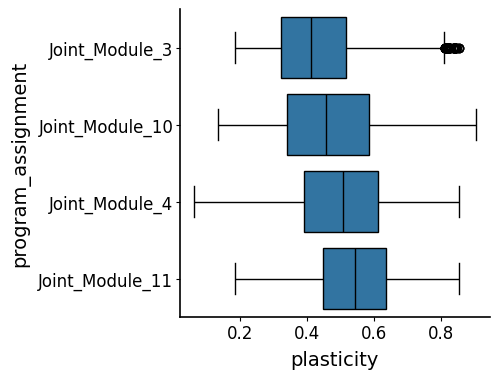

In [200]:
program_assignments = np.array(program_names)[hotspot_scores[program_names].apply(lambda x: np.argmax(x), axis=1)]
program_assignments = pd.DataFrame(program_assignments, index = hotspot_scores.apply(lambda x: f'{x.Sample}.{x.name}', axis=1))

summary_plasticities['program_assignment'] = np.nan
overlapping = np.intersect1d(program_assignments.index, summary_plasticities.index)
summary_plasticities.loc[overlapping, 'program_assignment'] = program_assignments.loc[overlapping].values

modules = ['Joint_Module_3', 'Joint_Module_4', 'Joint_Module_10', 'Joint_Module_11']
_order = summary_plasticities.groupby('program_assignment').agg({'plasticity': 'median'}).loc[modules].sort_values(by='plasticity').index

with mplscience.style_context():
    sns.boxplot(data=summary_plasticities, y='program_assignment', x='plasticity', order=_order, linecolor='black')
    # plt.savefig('./figures/plasticity_distribution_community.pdf', bbox_inches='tight')
    plt.show()

## Figure 3f

In [12]:
LAYER, PUCK = 'Layer1', 'Puck1'

adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad')
tree = pic.load(open(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_hybrid.pkl', 'rb'))
character_matrix = pd.read_csv(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_character_matrix.tsv', sep='\t', index_col = 0)
state_to_indel = pic.load(open(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_state2indel.pkl', 'rb'))

percent_uncut = character_matrix.apply(lambda x: len(x[x==0]) / len(x[x!=-1]), axis=1)
kii = percent_uncut[percent_uncut < 0.8].index.values

tree.remove_leaves_and_prune_lineages(np.setdiff1d(tree.leaves, kii))
tree.remove_leaves_and_prune_lineages(np.setdiff1d(tree.leaves, adata.obs_names))

adata.obs['tumor'] = 'False'
adata.obs.loc[tree.leaves, 'tumor'] = 'True'

print(f"Read in tree with {len(tree.leaves)} leaves ({round(len(tree.leaves) / adata.shape[0] * 100, 3)}% of all spots).")

character_matrix = tree.character_matrix.copy()
priors = tree.priors

allele_table = tree_utilities.character_matrix_to_allele_table(character_matrix, state_to_indel, keep_ambiguous=False)

Read in tree with 2272 leaves (18.397% of all spots).


  0%|          | 0/2272 [00:00<?, ?it/s]

In [13]:
adata = adata.raw.to_adata()
adata.layers['counts'] = adata.X.copy()
adata.layers["logged"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e6, layer='logged')
sc.pp.log1p(adata, layer='logged')

adata.layers['scaled'] = adata.layers['logged'].copy()

sc.pp.scale(adata, layer='scaled')

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
community_module_genes = pd.read_csv(f"{DATA_DIR}/hotspot_modules_consensus.tsv", sep='\t', index_col = 0)
program_names = [mod for mod in community_module_genes['Community_Module'].unique() if type(mod) == str]

for program_name, group in community_module_genes.groupby('Community_Module'):

    if type(program_name) != str:
        continue

    group['Gene'] = group.index.values
    unique_modules = group['Module'].unique()

    genes = group['Gene'].value_counts()
    module_genes = genes[genes > int(0.25 * len(unique_modules))].index.values

    if len(module_genes) < 1:
        continue

    sc.tl.score_genes(adata, module_genes, ctrl_size=100, n_bins=30, score_name=program_name, use_raw=False, layer='scaled')
    adata.obs[program_name] = (adata.obs[program_name] - adata.obs[program_name].mean()) / adata.obs[program_name].std()

In [9]:
tumor_id = 'Tumor-1'

tree_ = tree.copy()
tree_.remove_leaves_and_prune_lineages(np.setdiff1d(tree_.leaves, adata[adata.obs['tumor_id'] == tumor_id].obs_names))

genes = ['Vim', 'Slc2a1', 'Nkx2-1']

tree_.cell_meta = adata.obs.loc[tree_.leaves]
tree_.cell_meta[genes] = adata[tree_.leaves, genes].layers['logged'].todense()

node = tree_.root
clades_to_color = np.array(tree_.children(node))[:2]
clade_colors = ["#CD2626", "#1874CD"]

h = plt.figure(figsize=(7,12))
ax = plt.gca()
cas.pl.plot_matplotlib(
    tree_,
    orient='right',
    allele_table=allele_table,
    add_root=False,
    indel_colors=indel_colors,
    indel_priors=indel_priors,
    meta_data=['Joint_Module_1', 'Joint_Module_10', 'Joint_Module_3'],
    continuous_cmap='Reds',
    vmin=-0.5,
    vmax=3,
    figsize=(7, 12),
    clade_colors = dict(zip(clades_to_color, clade_colors)),
    ax=ax,
)
# plt.savefig('./puck1_layer1_tree_programs.png', dpi=300)

filling in multiindex table:   0%|          | 0/39138 [00:00<?, ?it/s]

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/cassiopeia/preprocess/utilities.py:526: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  allele_piv.loc[j[0]][j[1], cutsite] = val
100%|██████████| 

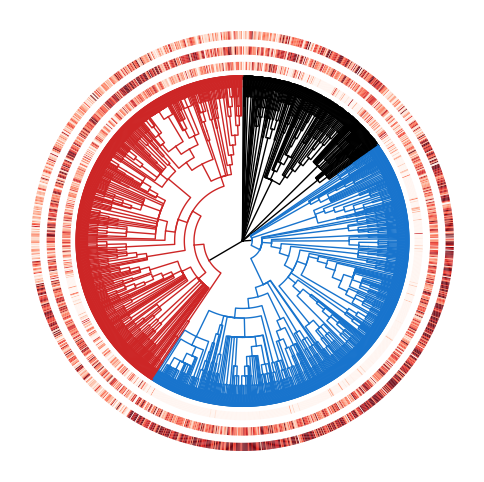

In [25]:
h = plt.figure(figsize=(6,6))
ax = plt.gca()
cas.pl.plot_matplotlib(
    tree_,
    meta_data=['Joint_Module_1', 'Joint_Module_10', 'Joint_Module_3'],
    continuous_cmap='Reds',
    vmin=-0.5,
    vmax=3,
    colorstrip_spacing=0.75,
    clade_colors = dict(zip(clades_to_color, clade_colors)),
    ax=ax,
)
plt.savefig('./puck1_layer1_tree_programs.png', dpi=300)
plt.show()

/tmp/ipykernel_54992/1721577140.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'clade-0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[tree_.leaves_in_subtree(clade), 'clade'] = f'clade-{i}'


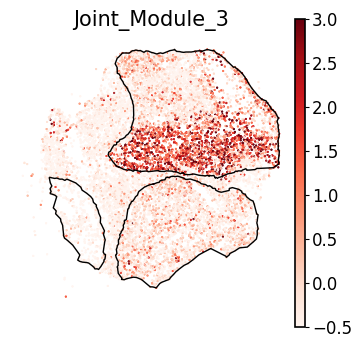

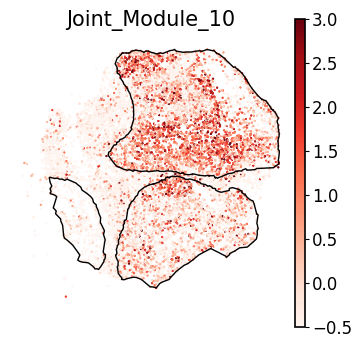

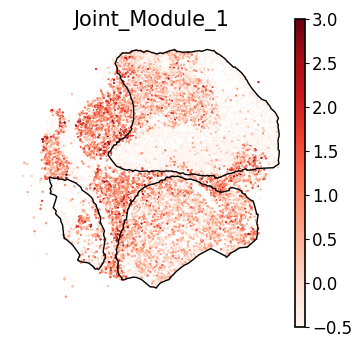

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


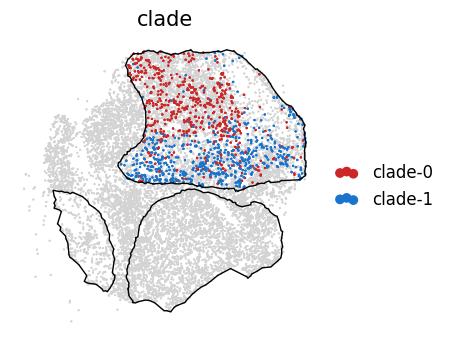

In [150]:
adata.obs['clade'] = np.nan

for i, clade in zip(range(2), clades_to_color):
    adata.obs.loc[tree_.leaves_in_subtree(clade), 'clade'] = f'clade-{i}'

adata.uns['clade_colors'] = ["#CD2626", "#1874CD"]

with mplscience.style_context():

    for grp in ['Joint_Module_3', 'Joint_Module_10', 'Joint_Module_1', 'clade']:
        
        fig = plt.figure()
        ax=plt.gca()
        
        if grp == 'clade':
            sq.pl.spatial_scatter(adata, size=1, shape=None, outline=False, cmap='Reds', layer='logged', na_color='lightgray', frameon=False, ax=ax)
            sq.pl.spatial_scatter(adata[adata.obs['clade'] != np.nan], color=grp, size=2, vmin=-0.5, vmax=3, groups = ['clade-1', 'clade-0'],
                                      shape=None, outline=False, cmap='Reds', layer='logged', na_color='lightgray', frameon=False, ax=ax)
            plt.gca().invert_yaxis()
            
        else:
            sq.pl.spatial_scatter(adata, color=grp, size=1, vmin=-0.5, vmax=3,
                                      shape=None, outline=False, cmap='Reds', layer='logged', na_color='lightgray', frameon=False, ax=ax)
        for tumor in adata.obs['tumor_id'].unique():
                if tumor != 'non-tumor':
                    spatial_utilities.plot_boundary(adata, ax=ax, color='black', tumor_id=tumor, max_distance=1e6)
        plt.savefig(f'./Layer1_Puck1_{grp}.png', dpi=300)
        plt.show()